In [1]:
import numpy as np
from xgboost import XGBRegressor 
from sklearn.metrics import r2_score 
from data_processor import DataReader, DataPrep
from sklearn.model_selection import GridSearchCV
from cv_generator import train_val_split, ExpandingWindowCV
from sklearn.ensemble import RandomForestRegressor
from model_eval import *
import pandas as pd
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from functools import partial
from lightgbm import LGBMRegressor
import warnings
import pandas_ta as ta

In [2]:
daily_data_path = r'data/daily_data'
intraday_data_path = r'data/intraday_data'
# intraday_df = DataReader.read_intraday_data(intraday_data_path)
# daily_df = DataReader.read_daily_data(daily_data_path)
# daily_df.to_pickle('daily_df.pkl')
# intraday_df.to_pickle('intraday_df.pkl')
daily_df = pd.read_pickle('daily_df.pkl')
intraday_df =  pd.read_pickle('intraday_df.pkl')
data_prep = DataPrep(intraday_df, daily_df)
target_df = data_prep.get_target(clip_MAD=True, normalize= True)
X_df = data_prep.get_features()#indicators= {'RSI_14':partial(ta.rsi, length= 14), 'RSI_5':partial(ta.rsi, length= 5)})
input_data = X_df.join(target_df[['y', 'y_actual_clipped']], how = 'right')

<Axes: >

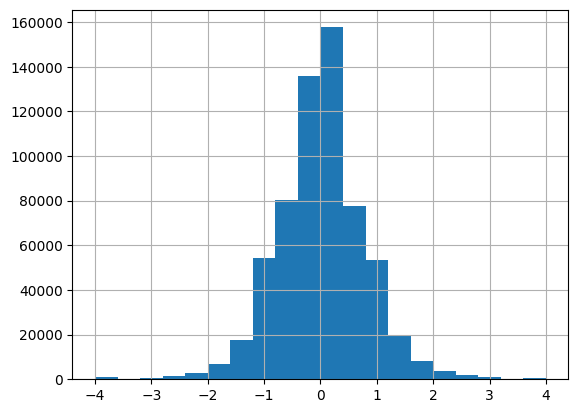

In [10]:
input_data.AD_preday.hist(bins = 20)

### Train Val Split

In [11]:
features = ['CumReturnResid',  'Rolling_Return_5d', 'Rolling_Return_10d', 'Rolling_Return_20d','NYSE', 'IntradayRSI']#, 'RSI_14']#,'Stock_Split', 'Dividend', 'Rolling_Return_20d', 'EarlyClose', 'NextHoliday']
clipped_returns = [col for col in input_data.columns if 'clipped' in col and 'Return' in col]
features = [f'Rolling_Return_{i}d_clipped' for i in [5, 10]]  + ['CumReturnResid', 'IntradayRSI', 'AD_preday', 'NYSE']# 'VolumeChangeNormalize']#, 'NYSE'] + 
input_data.dropna(subset=features, inplace=True)
train_data, val_data = train_val_split(input_data, 0.8)
print(features)
x_train, y_train = train_data[features], train_data['y']
x_val, y_val = val_data[features], val_data['y_actual_clipped']#val_data['y']
train_weights = train_data.MDV_63_sqrt.to_numpy()
val_weights = val_data.MDV_63_sqrt.to_numpy()

['Rolling_Return_5d_clipped', 'Rolling_Return_10d_clipped', 'CumReturnResid', 'IntradayRSI', 'AD_preday', 'NYSE']


In [ ]:
train_data[clipped_returns + ['y']].corr()['y'].sort_values()

In [ ]:
train_data[features + ['y']].corr()['y'].sort_values()


### Base random forest grid search

In [ ]:
rf = RandomForestRegressor()

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [2, 4, 6, 10],
    'min_samples_leaf': [2, 5, 10]
}

expand_wind_rf = ExpandingWindowCV(rf, rf_param_grid) 
expand_wind_rf.fit(x_train, y_train, train_weights)
print(expand_wind_rf.grid_search.best_params_)
model_rf = ModelEval(RandomForestRegressor(),features, x_train, y_train, train_weights, x_val.to_numpy(), y_val.to_numpy(), val_data.EST_VOL_preday.to_numpy(), val_weights,\
    grid_search= expand_wind_rf.grid_search)   
model_rf.to_pickle('xgboost_iter1')
print(model_rf.weighted_r2())
print(model_rf.feature_importance())
print(model_rf.feature_importance_MDA())

In [ ]:
GridSearchCV?

### Base xgboost Grid Search

In [ ]:
xgb = XGBRegressor()
xgb_param_grid = {
    'max_depth': [2, 4, 6],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0],
    'min_child_weight': [1, 5, 10],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

# expand_wind_xgb = ExpandingWindowCV(xgb, xgb_param_grid) 
# expand_wind_xgb.fit(x_train, y_train, train_weights)
# print(expand_wind_xgb.grid_search.best_params_)
best_param = {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 1, 'n_estimators': 100, 'reg_alpha': 1, 'reg_lambda': 2, 'subsample': 0.7}
model = ModelEval(XGBRegressor(),features, x_train, y_train, train_weights, x_val.to_numpy(), y_val.to_numpy(), val_data.EST_VOL_preday.to_numpy(), val_weights, best_params= best_param)
# model.to_pickle('xgboost_base')
print(model.weighted_r2())
print(model.feature_importance())
print(model.feature_importance_MDA())

### Base LightGBM Grid Search

In [12]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(verbosity = -1)

lgbm_param_grid = {
    'max_depth': [2, 4, 6],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 150],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.7, 1.0],
    'min_child_samples': [1, 5, 10],
    'lambda_l2': [0.05, 0.1, 0.2, 0.3]
}

# expand_wind_lgbm = ExpandingWindowCV(lgbm, lgbm_param_grid) 
# expand_wind_lgbm.fit(x_train, y_train, train_weights)
# model_lgbm = ModelEval(LGBMRegressor(verbosity = -1),features, x_train, y_train, train_weights, x_val.to_numpy(), y_val.to_numpy(), val_data.EST_VOL_preday.to_numpy(), val_weights, expand_wind_lgbm.grid_search)
# model_lgbm.to_pickle('lgbm_iter2')
# model_lgbm = load_model('lgbm_iter1')
# print(model_lgbm.grid_cv.best_params_)
best_params = {'colsample_bytree': 1.0, 'lambda_l1': 0.3, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_samples': 5, 'n_estimators': 100, 'subsample': 0.7}
model_lgbm = ModelEval(LGBMRegressor(verbosity = -1),features, x_train, y_train, train_weights, x_val.to_numpy(), y_val.to_numpy(), \
    val_data.EST_VOL_preday.to_numpy(), val_weights,best_params= best_params)
print(model_lgbm.weighted_r2())
print(model_lgbm.feature_importance())
print(model_lgbm.feature_importance_MDA())

0.0001336395210811414
{'AD_preday': 361, 'CumReturnResid': 336, 'Rolling_Return_10d_clipped': 272, 'Rolling_Return_5d_clipped': 244, 'IntradayRSI': 243, 'NYSE': 24}
{'IntradayRSI': 0.0008840857250379752, 'CumReturnResid': 0.0005733075943413472, 'Rolling_Return_5d_clipped': 0.0002457518533865999, 'AD_preday': 0.0001336815765144513, 'Rolling_Return_10d_clipped': 0.0001293448355627021, 'NYSE': -8.529190717069628e-07}


### Final Model

In [ ]:
x_train_all, y_train_all = input_data[features], input_data['y']
train_all_weights = input_data.MDV_63_sqrt.to_numpy()
best_params = {'colsample_bytree': 1.0, 'lambda_l1': 0.3, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_samples': 5, 'n_estimators': 100, 'subsample': 0.7}
lgbm_final = LGBMRegressor(verbosity = -1, ** best_params)
lgbm_final.fit(x_train_all, y_train_all, sample_weight=train_all_weights)

In [ ]:
# Open the file in binary-write mode and dump the model
with open(r'final_model\lgbm_model.pkl', 'wb') as file:
    pickle.dump(lgbm_final, file)